# Notebook 5 — Does arousal drive firing rate up or down?

**Summer course: data-analysis pitfalls**

Across many sessions we recorded a neuron's firing rate and, on each trial, the
animal's pupil size (a proxy for arousal). A colleague pooled all the trials and
fit a line:

> ### The claim
> *"Firing rate increases with arousal: across the dataset, pupil size and
> firing rate are positively correlated."*

Run it and you'll get a clear positive slope.

**The claim is backwards.** Your job is to work out *why*. `hints.md` has guiding
questions and `notebook5_solution.ipynb` has the answer.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family']       = 'Arial'
plt.rcParams['font.sans-serif']   = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42


In [2]:
d = np.load('data/data.npz')
pupil = d['pupil']                 # arousal proxy, per trial (0-1)
firing_rate = d['firing_rate']     # spikes/s, per trial
session_id = d['session_id']       # which session each trial came from
n_sessions = session_id.max() + 1
print(f'{len(pupil)} trials from {n_sessions} sessions')


420 trials from 7 sessions


## Pool all trials and fit firing rate vs. pupil


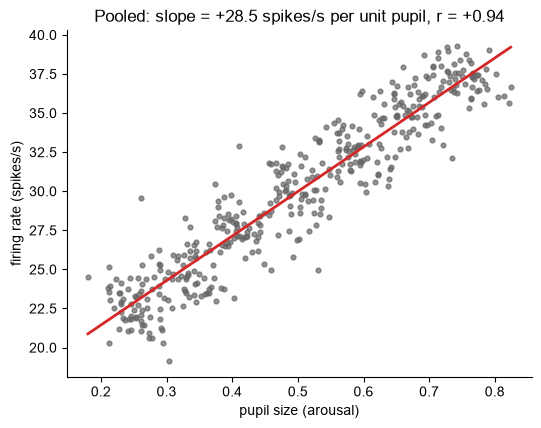

In [3]:
slope, intercept = np.polyfit(pupil, firing_rate, 1)   # linear fit to all trials
r = np.corrcoef(pupil, firing_rate)[0, 1]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(pupil, firing_rate, s=12, color='0.4', alpha=0.7)
xs = np.array([pupil.min(), pupil.max()])
ax.plot(xs, intercept + slope * xs, color='tab:red', lw=2)
ax.set_xlabel('pupil size (arousal)'); ax.set_ylabel('firing rate (spikes/s)')
ax.set_title(f'Pooled: slope = {slope:+.1f} spikes/s per unit pupil, r = {r:+.2f}')
plt.show()


A clear positive relationship: more arousal, more firing.
